# Descriptive analysis of green & brown employment based on EU-LFS data
Felix Zaussinger | 26.08.2022, updated 04.10.2022

**Core Analysis Goal(s)**
1. Create industry and regional plots based on final GBN classification (weighted and unweighted)
2. Create those plots both in an absolute and relative way

**Key Insight(s)**
1. Absolute numbers for unweighted shares closely correspond to independent figures of green employment based on EGSS data
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# needed for relative import in jupyter lab
module_path = os.path.abspath(os.path.join(os.pardir, os.pardir))
if module_path not in sys.path:
    sys.path.append(module_path)

from src import utils
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)
sns.set(rc={"figure.dpi": 300})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

In [2]:
# preprocessing flag
reprocess = False

In [3]:
from src.data.framework import Esco

esco = Esco()

#### Prepare EU-LFS data

In [4]:
from src.data.lfs import EuLfs
from src.data.framework import Classifications

# EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))
lfs = EuLfs(config=config)
year = 2019

lfs_data = lfs.read_preprocessed_file(
    year=year,
    input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares_and_earnings_incdecil_imputed",
)

In [5]:
lfs_data["NACE1D_label"]

0                                              Manufacturing
1                                              Manufacturing
2                                              Manufacturing
3                                              Manufacturing
4                                              Manufacturing
                                 ...                        
1412291    Professional, Scientific and Technical Activities
1412292    Professional, Scientific and Technical Activities
1412293    Water Supply; Sewerage, Waste Management and R...
1412294              Human Health and Social Work Activities
1412295    Electricity, Gas, Steam and Air Conditioning S...
Name: NACE1D_label, Length: 1412296, dtype: object

In [6]:
# add column for COAL (CPO Scenario)
# criteria for coal phase-out scenario
coal_occupations = {
    "Mining, manufacturing and construction supervisors": "312",
    "Mining and mineral processing plant operators": "811",
    "Manufacturing, mining, construction, and distribution managers": "132",
    "Mining and construction labourers": "931",
}
coal_industries = {
    "Electricity, Gas, Steam and Air Conditioning Supply": "D",
    "Mining and Quarrying": "B",
}

occ_subset = lfs_data["ISCO3D_label"].isin(list(coal_occupations.keys()))
ind_subset = lfs_data["NACE1D_label"].isin(list(coal_industries.keys()))

# use totals for COAL
lfs_data["COEFF_share_coal"] = lfs_data["COEFF"]

# mask based on criteria
lfs_data.loc[~(occ_subset & ind_subset), "COEFF_share_coal"] = np.nan

In [7]:
# shorten NACE labels
nace_short = pd.read_csv(
    os.path.join(
        useful_paths.data_raw,
        "classifications",
        "NACE_REV2_1d_section_codes_short_names.csv",
    ),
    index_col=0,
)

nace_mapping = dict(zip(nace_short.NACE1D_label, nace_short.NACE1D_label_short))
# lfs_data = lfs_data.replace(to_replace={"NACE1D_label": nace_mapping})
nace_short.columns

Index(['NACE1D_label', 'NACE1D_label_short', 'paper_selection'], dtype='object')

In [8]:
lfs_data = pd.merge(lfs_data, nace_short, on="NACE1D_label", how="left")

In [9]:
lfs_data

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,FTPT,HATLEV1D,HHTYPE,ILOSTAT,INCDECIL,INCDECIL_imputed,INCDECIL_median,INCDECIL_median_ceil,INCDECIL_median_floor,ISCO,ISCO3D,ISCO3D_label,MAINSTAT,NACE1D,NACE1D_label,NOBS,NUTS_ID,REFYEAR,REGION,REGIONW,SEX,WSTATOR,annual_earnings,category_sl,category_slt,country,country_code,decile,isco_code,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,COEFF_share_coal,NACE1D_label_short,paper_selection
0,52,82.5525,2.798390,1.399195,0.0000,79.754110,81.153305,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT12,2019,10,12,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
1,57,39.1925,1.328559,0.664280,0.0000,37.863941,38.528220,AT,AT,1,0,1,H,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT21,2019,20,21,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
2,37,76.8850,2.606271,1.303136,0.0000,74.278729,75.581864,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,10,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
3,47,70.1975,2.379576,1.189788,0.0000,67.817924,69.007712,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,30,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
4,37,25.4575,0.862966,0.431483,0.0000,24.594534,25.026017,AT,AT,2,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT34,2019,30,34,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412291,52,272.6200,0.000000,0.000000,0.0000,272.620000,272.620000,UK,UK,2,0,1,H,1,1,8.0,8.0,8.0,8.0,8.0,751,751,Food processing and related trades workers,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,1,1,NaN,neutral,neutral,United Kingdom,UK,8.0,751,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False
1412292,37,264.0200,0.000000,0.000000,0.0000,264.020000,264.020000,UK,UK,1,0,2,L,1,1,1.0,1.0,1.0,1.0,1.0,515,515,Building and housekeeping supervisors,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,2,1,NaN,neutral,neutral,United Kingdom,UK,1.0,515,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False
1412293,52,726.8300,670.920000,363.415000,0.0000,55.910000,363.415000,UK,UK,3,0,1,M,1,1,8.0,8.0,8.0,8.0,8.0,811,811,Mining and mineral processing plant operators,NaN,E,"Water Supply; Sewerage, Waste Management and R...",1.0,UKH,2019,H0,H0,1,1,NaN,brown,brown,United Kingdom,UK,8.0,811,0.923077,0.500000,0.00,0.076923,0.500000,NaN,"Water, Waste Mgmt.",True
1412294,37,664.3200,0.000000,0.000000,0.0000,664.320000,664.320000,UK,UK,2,0,1,H,1,1,7.0,7.0,7.0,7.0,7.0,231,231,University and higher education teachers,NaN,Q,Human Health and Social Work Activities,1.0,UKF,2019,F0,F0,2,1,NaN,neutral,neutral,United Kingdom,UK,7.0,231,0.000000,0.000000,0.00,1.000000,1.000000,NaN,"Health, Social",False


In [10]:
from src.visualization.visualize import EulfsVis

config_paths = "paths_config.yml"
config_data = "data_config.yml"
config_vis = "vis_config.yml"

# EU-LFS
eulfs_visualiser = EulfsVis(
    fn_config_data=config_data,
    fn_config_path=config_paths,
    fn_vis_config=config_vis,
    year=2019,
)

# assign updated data panel
eulfs_visualiser.data_panel = lfs_data


#### Incorporate publication guidelines by Eurostat (thresholds for sample sizes, etc.)

In all reports, including both published and unpublished papers, three thresholds related to cell size will be distinguished for LFS results:
- Confidentiality threshold - below three observations (unweighted sample), results must not be published;
- Reliability thresholds - regarding reliability restrictions, Eurostat defines two limits, called 'a' and 'b'. Reliability limits depend on the sample size and design in the individual Member States.
    - Estimates corresponding to a (weighted) population below limit 'a' must not be published;
    - Estimates corresponding to a (weighted) population between limit 'a' and limit ‘b’ may be published with a warning concerning their limited reliability. This applies to quarterly data, annual averages of quarterly data, yearly data and ad hoc module results. The limits vary across Member States, years, and type of dataset. The thresholds “a” and “b” are provided in the CSV files in the “datafileinfo” folders in the anonymised microdata releases. More information can be found also at the LFS Statistics Explained pages, section “Publication guidelines and thresholds”.

See: C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\datafileinfo

In [11]:
threshold_a = 3

### Visualisation

Define cols to process and plot

In [12]:
cols_to_calc = [
    "COEFF_share_green",
    "COEFF_share_coal",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_aggregate = [
    "COEFF",
    "COEFF_share_green",
    "COEFF_share_coal",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_plot = [
    "COEFF_share_green_relative",
    "COEFF_share_coal_relative",
    "COEFF_share_brown_sl_relative",
    "COEFF_share_brown_slt_relative",
    "COEFF_share_green",
    "COEFF_share_coal",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

eulfs_visualiser.cols_to_calc_all = cols_to_aggregate
eulfs_visualiser.cols_to_calc = cols_to_calc

#### Plot (by industry)

In [13]:
eulfs_visualiser.create_industry_boxplots(
    year=2019,
    cols_to_aggregate=cols_to_aggregate,
    cols_to_plot=cols_to_plot,
    grouping=["NACE1D_label", "COUNTRYW"],
    out_dir=os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "{year}",
        "employment_shares_by_industry",
    ),
)

INFO:src.visualization.visualize:GBN employment shares by industry.


T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\src\visualization\visualize.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.data_panel.groupby(grouping)[cols_to_aggregate].sum().reset_index()
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


plotting variable: COEFF_share_green_relative
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   NACE1D_label                    567 non-null    object  
 1   COUNTRYW                        567 non-null    category
 2   COEFF                           567 non-null    float64 
 3   COEFF_share_green               567 non-null    float64 
 4   COEFF_share_coal                567 non-null    float64 
 5   COEFF_share_brown_sl            567 non-null    float64 
 6   COEFF_share_brown_slt           567 non-null    float64 
 7   COEFF_relative                  564 non-null    float64 
 8   COEFF_share_green_relative      564 non-null    float64 
 9   COEFF_share_coal_relative       564 non-null    float64 
 10  COEFF_share_brown_sl_relative   564 non-null    float64 
 11  COEFF_share_brown_slt_relative  564 no

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

plotting variable: COEFF_share_coal_relative
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   NACE1D_label                    567 non-null    object  
 1   COUNTRYW                        567 non-null    category
 2   COEFF                           567 non-null    float64 
 3   COEFF_share_green               567 non-null    float64 
 4   COEFF_share_coal                567 non-null    float64 
 5   COEFF_share_brown_sl            567 non-null    float64 
 6   COEFF_share_brown_slt           567 non-null    float64 
 7   COEFF_relative                  564 non-null    float64 
 8   COEFF_share_green_relative      564 non-null    float64 
 9   COEFF_share_coal_relative       564 non-null    float64 
 10  COEFF_share_brown_sl_relative   564 non-null    float64 
 11  COEFF_share_brown_slt_relative  564 non

...

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

plotting variable: COEFF_share_brown_sl
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   NACE1D_label                    567 non-null    object  
 1   COUNTRYW                        567 non-null    category
 2   COEFF                           567 non-null    float64 
 3   COEFF_share_green               567 non-null    float64 
 4   COEFF_share_coal                567 non-null    float64 
 5   COEFF_share_brown_sl            567 non-null    float64 
 6   COEFF_share_brown_slt           567 non-null    float64 
 7   COEFF_relative                  564 non-null    float64 
 8   COEFF_share_green_relative      564 non-null    float64 
 9   COEFF_share_coal_relative       564 non-null    float64 
 10  COEFF_share_brown_sl_relative   564 non-null    float64 
 11  COEFF_share_brown_slt_relative  564 non-null

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

plotting variable: COEFF_share_brown_slt
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   NACE1D_label                    567 non-null    object  
 1   COUNTRYW                        567 non-null    category
 2   COEFF                           567 non-null    float64 
 3   COEFF_share_green               567 non-null    float64 
 4   COEFF_share_coal                567 non-null    float64 
 5   COEFF_share_brown_sl            567 non-null    float64 
 6   COEFF_share_brown_slt           567 non-null    float64 
 7   COEFF_relative                  564 non-null    float64 
 8   COEFF_share_green_relative      564 non-null    float64 
 9   COEFF_share_coal_relative       564 non-null    float64 
 10  COEFF_share_brown_sl_relative   564 non-null    float64 
 11  COEFF_share_brown_slt_relative  564 non-nul

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype

In [14]:
eulfs_visualiser.create_industry_boxplots(
    year=2019,
    cols_to_aggregate=cols_to_aggregate,
    cols_to_plot=cols_to_plot,
    grouping=["NACE1D_label"],
    out_dir=os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "{year}",
        "employment_shares_by_industry",
        "grouped_by_industry_only",
    ),
)

INFO:src.visualization.visualize:GBN employment shares by industry.
plotting variable: COEFF_share_green_relative
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412296 entries, 0 to 1412295
Data columns (total 53 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   AGE                             1412296 non-null  category
 1   COEFF                           1409373 non-null  float64 
 2   COEFF_share_brown_sl            1396997 non-null  float64 
 3   COEFF_share_brown_slt           1396997 non-null  float64 
 4   COEFF_share_green               1396997 non-null  float64 
 5   COEFF_share_neutral_sl          1396997 non-null  float64 
 6   COEFF_share_neutral_slt         1396997 non-null  float64 
 7   COUNTRY                         1412296 non-null  category
 8   COUNTRYW                        1412296 non-null  category
 9   DEGURBA                         1412296 non-null  category
 10  

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


plotting variable: COEFF_share_coal_relative
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412296 entries, 0 to 1412295
Data columns (total 53 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   AGE                             1412296 non-null  category
 1   COEFF                           1409373 non-null  float64 
 2   COEFF_share_brown_sl            1396997 non-null  float64 
 3   COEFF_share_brown_slt           1396997 non-null  float64 
 4   COEFF_share_green               1396997 non-null  float64 
 5   COEFF_share_neutral_sl          1396997 non-null  float64 
 6   COEFF_share_neutral_slt         1396997 non-null  float64 
 7   COUNTRY                         1412296 non-null  category
 8   COUNTRYW                        1412296 non-null  category
 9   DEGURBA                         1412296 non-null  category
 10  EDUC4WN                         1409996 non-null  category
 11  FTPT 

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


plotting variable: COEFF_share_brown_sl_relative
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412296 entries, 0 to 1412295
Data columns (total 53 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   AGE                             1412296 non-null  category
 1   COEFF                           1409373 non-null  float64 
 2   COEFF_share_brown_sl            1396997 non-null  float64 
 3   COEFF_share_brown_slt           1396997 non-null  float64 
 4   COEFF_share_green               1396997 non-null  float64 
 5   COEFF_share_neutral_sl          1396997 non-null  float64 
 6   COEFF_share_neutral_slt         1396997 non-null  float64 
 7   COUNTRY                         1412296 non-null  category
 8   COUNTRYW                        1412296 non-null  category
 9   DEGURBA                         1412296 non-null  category
 10  EDUC4WN                         1409996 non-null  category
 11  F

...

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


plotting variable: COEFF_share_brown_sl
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412296 entries, 0 to 1412295
Data columns (total 53 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   AGE                             1412296 non-null  category
 1   COEFF                           1409373 non-null  float64 
 2   COEFF_share_brown_sl            1396997 non-null  float64 
 3   COEFF_share_brown_slt           1396997 non-null  float64 
 4   COEFF_share_green               1396997 non-null  float64 
 5   COEFF_share_neutral_sl          1396997 non-null  float64 
 6   COEFF_share_neutral_slt         1396997 non-null  float64 
 7   COUNTRY                         1412296 non-null  category
 8   COUNTRYW                        1412296 non-null  category
 9   DEGURBA                         1412296 non-null  category
 10  EDUC4WN                         1409996 non-null  category
 11  FTPT      

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


plotting variable: COEFF_share_brown_slt
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412296 entries, 0 to 1412295
Data columns (total 53 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   AGE                             1412296 non-null  category
 1   COEFF                           1409373 non-null  float64 
 2   COEFF_share_brown_sl            1396997 non-null  float64 
 3   COEFF_share_brown_slt           1396997 non-null  float64 
 4   COEFF_share_green               1396997 non-null  float64 
 5   COEFF_share_neutral_sl          1396997 non-null  float64 
 6   COEFF_share_neutral_slt         1396997 non-null  float64 
 7   COUNTRY                         1412296 non-null  category
 8   COUNTRYW                        1412296 non-null  category
 9   DEGURBA                         1412296 non-null  category
 10  EDUC4WN                         1409996 non-null  category
 11  FTPT     

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


#### Plot (by region)

In [15]:
# sns.set_style("ticks")
# sns.set_context("paper", font_scale=1.5)
#
# perc_max = 3
# eulfs_visualiser.create_maps(
#     slice_by_industry=False,
#     vmin=0,
#     vmax=perc_max/100,
#     cmap="Oranges",
#     n_cats=perc_max*2,
#     out_dir=os.path.join(
#             useful_paths.figure_dir,
#             "03_eulfs",
#             "2019",
#             "employment_shares_by_region",
#             "NEW",
#             "cbars_fixed_at_{}_percent_discrete".format(perc_max)
#         ),
# )

In [16]:
# eulfs_visualiser.create_maps(
#     slice_by_industry=True,
#     vmin=0,
#     vmax=None,
#     cmap="Greys",
#     n_cats=None,
#     out_dir=os.path.join(
#         useful_paths.figure_dir,
#         "03_eulfs",
#         "2019",
#         "employment_shares_by_region",
#         "NEW",
#         "by_industry",
#     ),
# )

Bar charts by country

In [17]:
agg = {
    "NOBS": np.sum,
    "COEFF": np.sum,
    "COEFF_share_brown_sl": np.sum,
    "COEFF_share_brown_slt": np.sum,
    "COEFF_share_green": np.sum,
    "COEFF_share_neutral_sl": np.sum,
    "COEFF_share_neutral_slt": np.sum,
}

data_agg = lfs_data.groupby(["COUNTRYW", "NACE1D_label"]).aggregate(agg)

# calculate relative shares at regional level
for col in data_agg.columns[data_agg.columns.str.startswith("COEFF_")]:
    data_agg["{}_relative".format(col)] = data_agg[col] / data_agg["COEFF"]

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_6396\3638558530.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_agg = lfs_data.groupby(["COUNTRYW", "NACE1D_label"]).aggregate(agg)
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_6396\3638558530.py:11: FutureWarning: The provided callable <function sum at 0x00000222837AA840> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data_agg = lfs_data.groupby(["COUNTRYW", "NACE1D_label"]).aggregate(agg)
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_6396\3638558530.py:11: FutureWarning: The provided callable <function sum at 0x00000222837AA840> is currently using SeriesGroupBy.sum. In a future version of pandas, th

In [18]:
data_agg_final = data_agg[data_agg["NOBS"] >= threshold_a]

#### Plots by industry (w/o country grouping)

In [19]:
df = lfs_data
for col in cols_to_aggregate:
    df["{}_relative".format(col)] = df[col] / df["COEFF"]

df

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,FTPT,HATLEV1D,HHTYPE,ILOSTAT,INCDECIL,INCDECIL_imputed,INCDECIL_median,INCDECIL_median_ceil,INCDECIL_median_floor,ISCO,ISCO3D,ISCO3D_label,MAINSTAT,NACE1D,NACE1D_label,NOBS,NUTS_ID,REFYEAR,REGION,REGIONW,SEX,WSTATOR,annual_earnings,category_sl,category_slt,country,country_code,decile,isco_code,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,COEFF_share_coal,NACE1D_label_short,paper_selection,COEFF_relative,COEFF_share_green_relative,COEFF_share_coal_relative,COEFF_share_brown_sl_relative,COEFF_share_brown_slt_relative
0,52,82.5525,2.798390,1.399195,0.0000,79.754110,81.153305,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT12,2019,10,12,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
1,57,39.1925,1.328559,0.664280,0.0000,37.863941,38.528220,AT,AT,1,0,1,H,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT21,2019,20,21,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
2,37,76.8850,2.606271,1.303136,0.0000,74.278729,75.581864,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,10,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
3,47,70.1975,2.379576,1.189788,0.0000,67.817924,69.007712,AT,AT,3,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT31,2019,30,31,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
4,37,25.4575,0.862966,0.431483,0.0000,24.594534,25.026017,AT,AT,2,0,1,M,1,1,NaN,NaN,NaN,NaN,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT34,2019,30,34,1,1,NaN,neutral,neutral,NaN,NaN,NaN,132,0.033898,0.016949,0.00,0.966102,0.983051,NaN,Manufacturing,True,1.0,0.00,NaN,0.033898,0.016949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412291,52,272.6200,0.000000,0.000000,0.0000,272.620000,272.620000,UK,UK,2,0,1,H,1,1,8.0,8.0,8.0,8.0,8.0,751,751,Food processing and related trades workers,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,1,1,NaN,neutral,neutral,United Kingdom,UK,8.0,751,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False,1.0,0.00,NaN,0.000000,0.000000
1412292,37,264.0200,0.000000,0.000000,0.0000,264.020000,264.020000,UK,UK,1,0,2,L,1,1,1.0,1.0,1.0,1.0,1.0,515,515,Building and housekeeping supervisors,NaN,M,"Professional, Scientific and Technical Activities",1.0,UKN,2019,N0,N0,2,1,NaN,neutral,neutral,United Kingdom,UK,1.0,515,0.000000,0.000000,0.00,1.000000,1.000000,NaN,Profess. Activ.,False,1.0,0.00,NaN,0.000000,0.000000
1412293,52,726.8300,670.920000,363.415000,0.0000,55.910000,363.415000,UK,UK,3,0,1,M,1,1,8.0,8.0,8.0,8.0,8.0,811,811,Mining and mineral processing plant operators,NaN,E,"Water Supply; Sewerage, Waste Management and R...",1.0,UKH,2019,H0,H0,1,1,NaN,brown,brown,United Kingdom,UK,8.0,811,0.923077,0.500000,0.00,0.076923,0.500000,NaN,"Water, Waste Mgmt.",True,1.0,0.00,NaN,0.923077,0.500000
1412294,37,664.3200,0.000000,0.000000,0.0000,664.320000,664.320000,UK,UK,2,0,1,H,1,1,7.0,7.0,7.0,7.0,7.0,231,231,University and higher education teachers,NaN,Q,Human Health and Social Work Activities,1.0,UKF,2019,F0,F0,2,1,NaN,neutral,neutral,United Kingdom,UK,7.0,231,0.000000,0.000000,0.

Diskussion mit Flo bzgl Medianen in diesem Plot:
- es macht Sinn, das 50% aller Jobs über alle Länder in einem der Sektoren total neutral sind
- deshalb sind die Mediane auch grossteils gleich null

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\seaborn\_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


NACE1D_label
Accommodation and Food Service Activities                                                                                    0.000000
Activities of Extraterritorial Organisations and Bodies                                                                      0.000000
Activities of Households as Employers; Undifferentiated Goods and Services Producing Activities of Households for Own Use    0.000000
Administrative and Support Service Activities                                                                                0.000000
Agriculture, Forestry and Fishing                                                                                            0.000000
Arts, Entertainment and Recreation                                                                                           0.000000
Construction                                                                                                                 0.000000
Education                                        

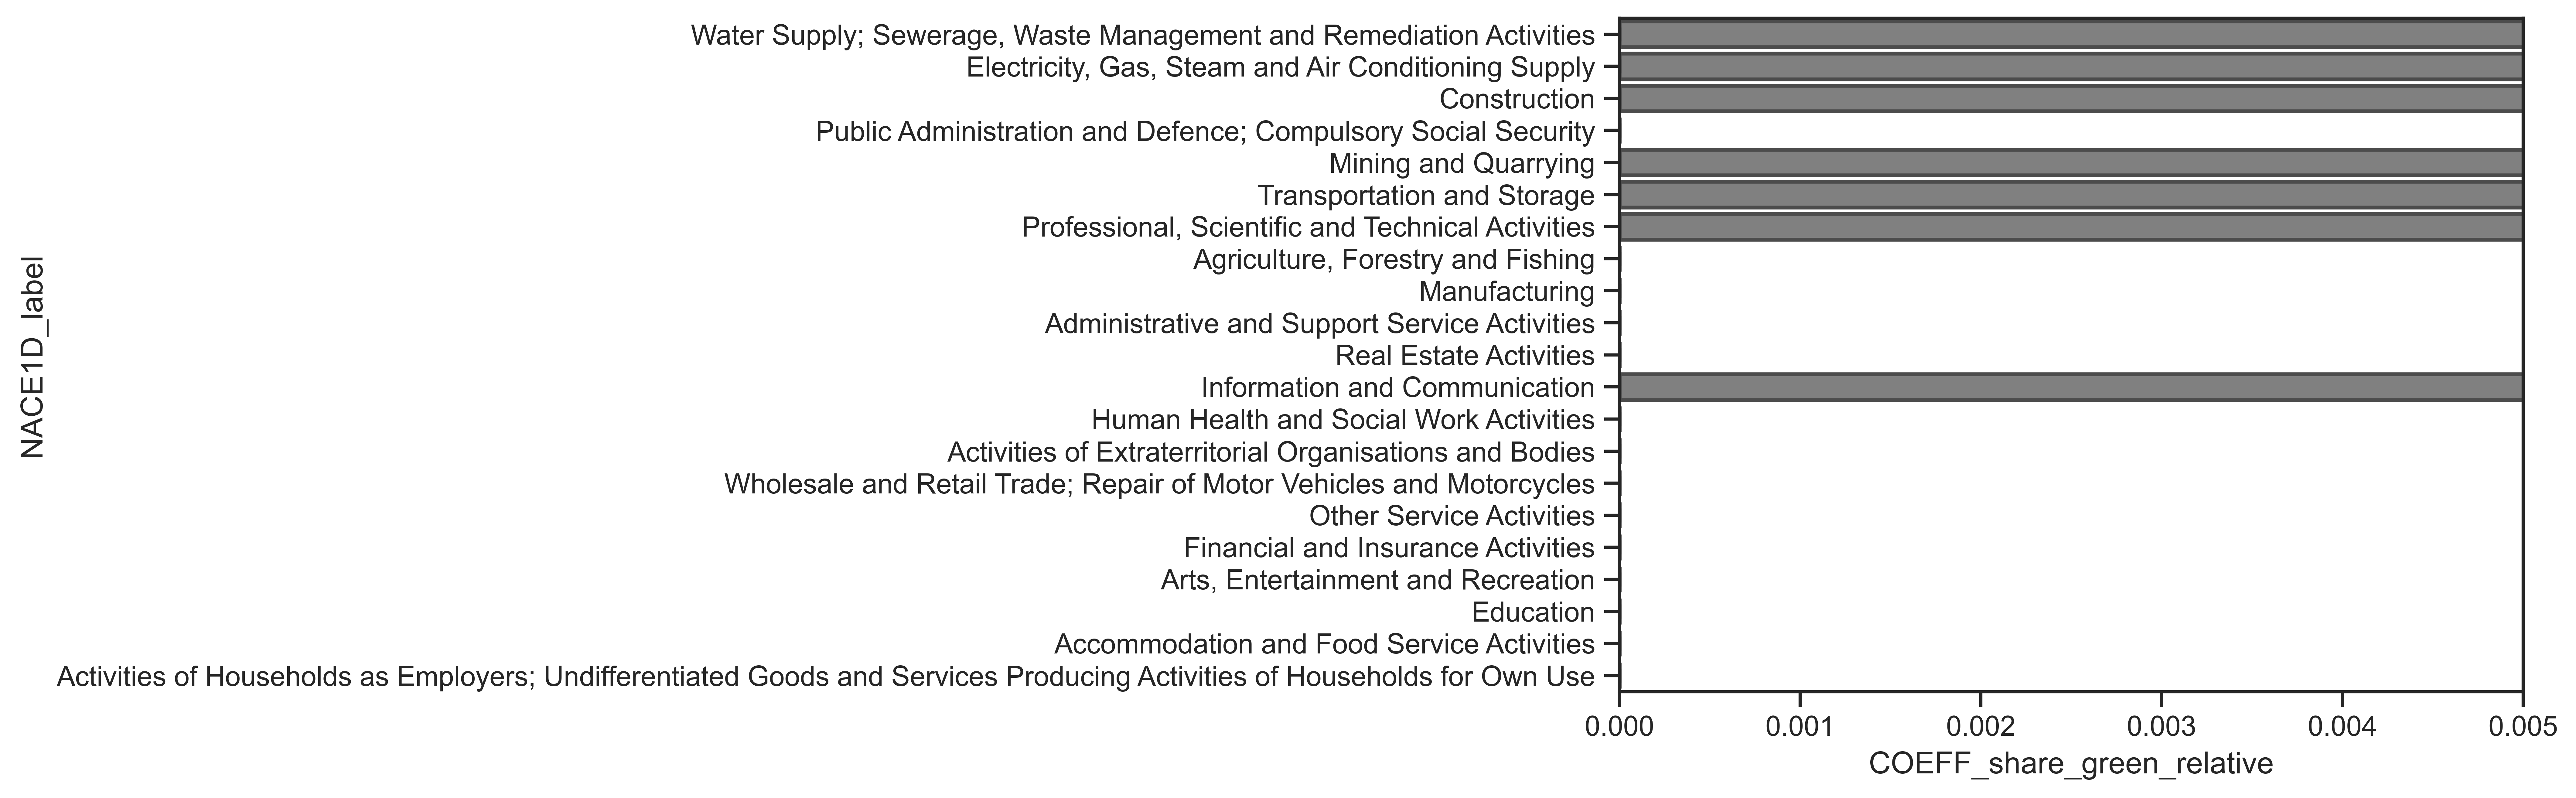

In [20]:
x = "COEFF_share_green_relative"
y = "NACE1D_label"

ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    order=df.groupby(y)[x].mean().sort_values(ascending=False).index.values,
    color=".5",
    fliersize=1,
    showfliers=True,
)

ax.set_xlim(0, 0.005)

df.groupby(y)[x].median()

Bar plots to also show absolute numbers

#### Prepare data for import in thinkcell (new graphs for resubmission, 16.10.2023)

Our estimate of 212.5 Million compares well with the [offical size of labour force](https://data.worldbank.org/indicator/SL.TLF.TOTL.IN?locations=EU), 217.8 Million (some countries are missing in our estimates).

In [21]:
df.COEFF.sum()

212628832.805

However, about 1.1 percent of observations could not be assigned a calculated COEFF g/b/n share because of **missing ISCO3D labels** - dropped for further analysis.

In [22]:
utils.perc_missing(df)

,missing_obs_abs,missing_obs_rel
AGE,0.0,0.000000
COEFF,2923.0,0.002070
COEFF_share_brown_sl,15299.0,0.010833
COEFF_share_brown_slt,15299.0,0.010833
COEFF_share_green,15299.0,0.010833
COEFF_share_neutral_sl,15299.0,0.010833
COEFF_share_neutral_slt,15299.0,0.010833
COUNTRY,0.0,0.000000
COUNTRYW,0.0,0.000000
DEGURBA,0.0,0.000000


This is why we decided to reduce the number of observations by dropping those entries wo ISCO 3D labels (n=15299).

In [23]:
df.loc[df['COEFF_share_green'].isna(), :]

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,FTPT,HATLEV1D,HHTYPE,ILOSTAT,INCDECIL,INCDECIL_imputed,INCDECIL_median,INCDECIL_median_ceil,INCDECIL_median_floor,ISCO,ISCO3D,ISCO3D_label,MAINSTAT,NACE1D,NACE1D_label,NOBS,NUTS_ID,REFYEAR,REGION,REGIONW,SEX,WSTATOR,annual_earnings,category_sl,category_slt,country,country_code,decile,isco_code,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,COEFF_share_coal,NACE1D_label_short,paper_selection,COEFF_relative,COEFF_share_green_relative,COEFF_share_coal_relative,COEFF_share_brown_sl_relative,COEFF_share_brown_slt_relative
99993,32,106.6500,NaN,NaN,NaN,NaN,NaN,BE,BE,2,0,1,M,1,1,NaN,5.0,5.0,5.0,5.0,633,633,NaN,1,A,"Agriculture, Forestry and Fishing",NaN,BE34,2019,34,34,1,1,24608.000000,NaN,NaN,Belgium,BE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agri., Forest., Fish.",True,1.0,NaN,NaN,NaN,NaN
99994,72,183.2700,NaN,NaN,NaN,NaN,NaN,BE,BE,3,0,2,M,1,1,NaN,5.0,5.0,5.0,5.0,633,633,NaN,4,A,"Agriculture, Forestry and Fishing",NaN,BE33,2019,33,33,2,1,24608.000000,NaN,NaN,Belgium,BE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agri., Forest., Fish.",True,1.0,NaN,NaN,NaN,NaN
99995,52,117.7700,NaN,NaN,NaN,NaN,NaN,BE,BE,3,0,1,H,1,1,NaN,5.0,5.0,5.0,5.0,633,633,NaN,1,A,"Agriculture, Forestry and Fishing",NaN,BE34,2019,34,34,1,1,24608.000000,NaN,NaN,Belgium,BE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agri., Forest., Fish.",True,1.0,NaN,NaN,NaN,NaN
99996,62,53.0200,NaN,NaN,NaN,NaN,NaN,BE,BE,3,0,1,H,1,1,NaN,5.0,5.0,5.0,5.0,633,633,NaN,1,A,"Agriculture, Forestry and Fishing",NaN,BE34,2019,34,34,2,1,24608.000000,NaN,NaN,Belgium,BE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agri., Forest., Fish.",True,1.0,NaN,NaN,NaN,NaN
99997,27,525.4700,NaN,NaN,NaN,NaN,NaN,BE,BE,2,0,1,M,1,1,NaN,5.0,5.0,5.0,5.0,633,633,NaN,1,A,"Agriculture, Forestry and Fishing",NaN,BE32,2019,32,32,1,1,24608.000000,NaN,NaN,Belgium,BE,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agri., Forest., Fish.",True,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374088,27,87.2325,NaN,NaN,NaN,NaN,NaN,SK,SK,1,0,1,H,1,1,7.0,7.0,7.0,7.0,7.0,420,420,NaN,1,M,"Professional, Scientific and Technical Activities",NaN,SK02,2019,02,02,1,1,10030.000000,NaN,NaN,Slovakia,SK,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Profess. Activ.,False,1.0,NaN,NaN,NaN,NaN
1374089,57,48.7975,NaN,NaN,NaN,NaN,NaN,SK,SK,2,0,1,M,1,1,10.0,10.0,10.0,10.0,10.0,120,120,NaN,1,G,Wholesale and Retail Trade; Repair of Motor Ve...,NaN,SK02,2019,02,02,2,1,20933.911309,NaN,NaN,Slovakia,SK,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Trade, Repair",True,1.0,NaN,NaN,NaN,NaN
1374090,57,55.3775,NaN,NaN,NaN,NaN,NaN,SK,SK,2,0,1,H,1,1,10.0,10.0,10.0,10.0,10.0,310,310,NaN,1,D,"Electricity, Gas, Steam and Air Conditioning S...",NaN,SK02,2019,02,02,1,1,20933.911309,NaN,NaN,Slovakia,SK,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Electricity, Gas",True,1.0,NaN,NaN,NaN,NaN
1374094,32,78.9725,NaN,NaN,NaN,NaN,NaN,SK,SK,2,0,1,M,1,1,5.0,5.0,5.0,5.0,5.0,910,910,NaN,1,I,Accommodation and Food Service Activities,NaN,SK03,2019,03,03,2,1,8119.000000,NaN,NaN,Slovakia,SK,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Accom., Food",False,1.0,NaN,NaN,NaN,NaN


In [24]:
df_v2 = df.loc[~df['COEFF_share_green'].isna(), :]
df_v2.COEFF.sum()

211217479.8875001

#### Compile summary of countries providing data and their membership status

In [49]:
#df_v2.loc[df_v2.COUNTRY == 'EE', ['ISCO3D', 'REGIONW']]
df_v2.COUNTRY.unique().shape

(27,)

In [50]:
# calculate potential-to-abate share as % emission intensive (brown SL) - % hard-to-abate (brown SLT)
df_v2["share_brown_diff"] = df_v2["share_brown_sl"] - df_v2["share_brown_slt"]

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_6396\3349435055.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v2["share_brown_diff"] = df_v2["share_brown_sl"] - df_v2["share_brown_slt"]


In [51]:
# relabel
relabel_dict = {
    "share_brown_sl": "share_emission-intensive",
    "share_brown_slt": "share_hard-to-abate",
    "share_brown_diff": "share_potential-to-abate",
    "share_green": "share_low-carbon",
    "share_neutral_sl": "share_neutral",
}

df_v2 = df_v2.rename(columns=relabel_dict)

In [ ]:
df_v2

Check if all percentages sum to 100 -> fine!

In [52]:
low_level_categories = ["share_hard-to-abate", "share_potential-to-abate", "share_low-carbon", "share_neutral"]
assert np.isclose(df_v2.loc[:, low_level_categories].sum(axis=1), 1).all()

Get absolute employment numbers by multipling each share with the employment coefficient

In [53]:
for cat in low_level_categories:
    name_1 = "coeff_"
    name_2 = cat.split("_")[1]
    name = name_1 + name_2
    print(name)
    df_v2[name] = df_v2[cat] * df_v2["COEFF"]

coeff_hard-to-abate
coeff_potential-to-abate
coeff_low-carbon
coeff_neutral


In [70]:
df_v2.columns

Index(['AGE', 'COEFF', 'COEFF_share_brown_sl', 'COEFF_share_brown_slt',
       'COEFF_share_green', 'COEFF_share_neutral_sl',
       'COEFF_share_neutral_slt', 'COUNTRY', 'COUNTRYW', 'DEGURBA', 'EDUC4WN',
       'FTPT', 'HATLEV1D', 'HHTYPE', 'ILOSTAT', 'INCDECIL', 'INCDECIL_imputed',
       'INCDECIL_median', 'INCDECIL_median_ceil', 'INCDECIL_median_floor',
       'ISCO', 'ISCO3D', 'ISCO3D_label', 'MAINSTAT', 'NACE1D', 'NACE1D_label',
       'NOBS', 'NUTS_ID', 'REFYEAR', 'REGION', 'REGIONW', 'SEX', 'WSTATOR',
       'annual_earnings', 'category_sl', 'category_slt', 'country',
       'country_code', 'decile', 'isco_code', 'share_emission-intensive',
       'share_hard-to-abate', 'share_low-carbon', 'share_neutral',
       'share_neutral_slt', 'COEFF_share_coal', 'NACE1D_label_short',
       'paper_selection', 'COEFF_relative', 'COEFF_share_green_relative',
       'COEFF_share_coal_relative', 'COEFF_share_brown_sl_relative',
       'COEFF_share_brown_slt_relative', 'share_potential-to-ab

In [73]:
df_v2['NUTS_ID'].unique().shape

(226,)

#### Top regions per category differentiated by sectoral contributions
Comment Flo: 
- I think it would be nice to have a table of the top 20 regions for high-carbon, hard-to-abate, potential-to-abate and low-carbon in the SI.
- For each, I would like the table to show the sectoral distribution of the share.
- Then you could add a few sentences in this paragraph describing the results.

In [129]:
shapefile = pd.read_excel(
    os.path.join(
            useful_paths.data_raw, "eu-jtf", "EU_shapefile_nuts_0123.xlsx"
        ),
    index_col=0
)[['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NUTS_NAME']]

194 regions matched at NUTS 2 level

In [130]:
# compute regional shares
res = df_v2.groupby(['NUTS_ID'])[['share_hard-to-abate', 'share_potential-to-abate', 'share_low-carbon', 'share_neutral']].mean().reset_index()

# add metadata
res_meta = pd.merge(res, shapefile, on='NUTS_ID', how='left')

res_meta.to_csv(
    os.path.join(
        useful_paths.data_processed, "eulfs", "eulfs_2019_shares_by_region.csv"
    )
)

In [131]:
res_meta

,NUTS_ID,share_hard-to-abate,share_potential-to-abate,share_low-carbon,share_neutral,LEVL_CODE,CNTR_CODE,NUTS_NAME
0,AT11,0.008456,0.014453,0.017477,0.959613,2.0,AT,Burgenland
1,AT12,0.010416,0.021020,0.020076,0.948488,2.0,AT,Niederösterreich
2,AT13,0.006272,0.008312,0.017673,0.967743,2.0,AT,Wien
3,AT21,0.010023,0.024186,0.020528,0.945263,2.0,AT,Kärnten
4,AT22,0.010319,0.024847,0.021762,0.943071,2.0,AT,Steiermark
...,...,...,...,...,...,...,...,...
220,UKJ,0.006390,0.005030,0.017418,0.971162,1.0,UK,South East (England)
221,UKK,0.007751,0.009610,0.019127,0.963512,1.0,UK,South West (England)
222,UKL,0.009172,0.013634,0.017213,0.959980,1.0,UK,Wales
223,UKM,0.009282,0.008536,0.021902,0.960280,1.0,UK,Scotland


In [164]:
# calculate sectoral composition by region
res2 = df_v2.groupby(['NUTS_ID', 'NACE1D_label'])[['share_hard-to-abate', 'share_potential-to-abate', 'share_low-carbon', 'share_neutral']].mean().reset_index()
res2_meta = pd.merge(res2, shapefile, on='NUTS_ID', how='left')

res2_meta.to_csv(
    os.path.join(
        useful_paths.data_processed, "eulfs", "eulfs_2019_shares_by_region_and_sector.csv"
    )
)

In [165]:
res2_meta

,NUTS_ID,NACE1D_label,share_hard-to-abate,share_potential-to-abate,share_low-carbon,share_neutral,LEVL_CODE,CNTR_CODE,NUTS_NAME
0,AT11,Accommodation and Food Service Activities,0.000432,0.001529,0.004683,0.993356,2.0,AT,Burgenland
1,AT11,Activities of Households as Employers; Undiffe...,0.000000,0.000000,0.000000,1.000000,2.0,AT,Burgenland
2,AT11,Administrative and Support Service Activities,0.000453,0.000000,0.006147,0.993400,2.0,AT,Burgenland
3,AT11,"Agriculture, Forestry and Fishing",0.001697,0.008544,0.004404,0.985355,2.0,AT,Burgenland
4,AT11,"Arts, Entertainment and Recreation",0.000642,0.001284,0.003752,0.994322,2.0,AT,Burgenland
...,...,...,...,...,...,...,...,...,...
4494,UKN,Public Administration and Defence; Compulsory ...,0.003282,0.001648,0.027444,0.967626,1.0,UK,Northern Ireland
4495,UKN,Real Estate Activities,0.002886,0.001082,0.004141,0.991891,1.0,UK,Northern Ireland
4496,UKN,Transportation and Storage,0.002830,0.001023,0.025278,0.970870,1.0,UK,Northern Ireland
4497,UKN,"Water Supply; Sewerage, Waste Management and R...",0.031662,0.011696,0.166667,0.789976,1.0,UK,Northern Ireland


read nace shortnames

In [226]:
df_nace_dict = pd.read_csv(
    os.path.join(
        useful_paths.data_raw, "classifications", 'NACE_REV2_1d_section_codes_short_names.csv'
    ),
    index_col=0
)

nace_dict = dict(zip(df_nace_dict['NACE1D_label'], df_nace_dict['NACE1D_label_short']))
nace_dict

{'Agriculture, Forestry and Fishing': 'Agri., Forest., Fish.',
 'Mining and Quarrying': 'Mining',
 'Manufacturing': 'Manufacturing',
 'Electricity, Gas, Steam and Air Conditioning Supply': 'Electricity, Gas',
 'Water Supply; Sewerage, Waste Management and Remediation Activities': 'Water, Waste Mgmt.',
 'Construction': 'Construction',
 'Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles': 'Trade, Repair',
 'Transportation and Storage': 'Transport',
 'Accommodation and Food Service Activities': 'Accom., Food',
 'Information and Communication': 'ICT',
 'Financial and Insurance Activities': 'Financial',
 'Real Estate Activities': 'Real Estate',
 'Professional, Scientific and Technical Activities': 'Profess. Activ.',
 'Administrative and Support Service Activities': 'Service Activ.',
 'Public Administration and Defence; Compulsory Social Security': 'Public Admin.',
 'Education': 'Education',
 'Human Health and Social Work Activities': 'Health, Social',
 'Arts, Entertainmen

In [197]:
# find n regions with highest average share by category
n = 5

# select target category
cat = low_level_categories[0]

# sort by target category and select n highest rows
candidate_regions = res_meta.sort_values(cat, ascending=False).head(n)

# create label to indicate the row with the total share across all industries
candidate_regions['NACE1D_label'] = 'TOTAL'
candidate_regions

,NUTS_ID,share_hard-to-abate,share_potential-to-abate,share_low-carbon,share_neutral,LEVL_CODE,CNTR_CODE,NUTS_NAME,NACE1D_label
200,RO42,0.022818,0.037095,0.018235,0.921851,2.0,RO,Vest,TOTAL
146,HU21,0.019898,0.064921,0.028914,0.886267,2.0,HU,Közép-Dunántúl,TOTAL
72,DEG0,0.018624,0.033570,0.021642,0.926164,2.0,DE,Thüringen,TOTAL
147,HU22,0.018595,0.052439,0.027287,0.901680,2.0,HU,Nyugat-Dunántúl,TOTAL
34,CZ08,0.018100,0.057008,0.024238,0.900654,2.0,CZ,Moravskoslezsko,TOTAL


In [225]:
# find n regions with highest average share by category
n = 5

# select target category
cat = low_level_categories[2]

# sort by target category and select n highest rows
candidate_regions = res_meta.sort_values(cat, ascending=False).head(n)

# create label to indicate the row with the total share across all industries
candidate_regions['NACE1D_label'] = 'TOTAL'
candidate_regions

# prepare container to store region x sectors df
dfs = []

# match sectoral composition to overall share at regional level (TOTAL)
for i, s in candidate_regions.iterrows():
    nuts_id = s['NUTS_ID']
    
    # find n sectors with highest share in particular region
    sectoral_comp = res2_meta[res2_meta.NUTS_ID == nuts_id].sort_values(cat, ascending=False).head(n)
    sectoral_comp = sectoral_comp[candidate_regions.columns.values]
    
    regional_stats = pd.concat([candidate_regions.loc[candidate_regions.NUTS_ID == nuts_id], sectoral_comp])
    
    dfs.append(regional_stats)

# concat regions together
dfs_out = pd.concat(dfs)

# focus on important columns and re-sort
cols_to_keep = ["NUTS_NAME", "NUTS_ID", "CNTR_CODE", "NACE1D_label", cat]
dfs_out_final = dfs_out[cols_to_keep].reset_index(drop=True)

# rename long nace names to shorter versions
dfs_out_final = dfs_out_final.replace({'NACE1D_label': nace_dict})

# filename
fname = "top_{n}_regions_{category}_by_top_{i}_sectors.csv".format(n=n, category=cat, i=n)

# save file
dfs_out_final.to_csv(
    os.path.join(
        useful_paths.data_processed, "eulfs", fname
    ),
    encoding="utf-8-sig"
)

In [221]:
dfs_out_final

,NUTS_NAME,NUTS_ID,CNTR_CODE,NACE1D_label,share_potential-to-abate
0,Közép-Dunántúl,HU21,HU,TOTAL,0.064921
1,Közép-Dunántúl,HU21,HU,Mining,0.171575
2,Közép-Dunántúl,HU21,HU,Manufacturing,0.155238
3,Közép-Dunántúl,HU21,HU,"Water, Waste Mgmt.",0.072591
4,Közép-Dunántúl,HU21,HU,"Electricity, Gas",0.054740
5,Közép-Dunántúl,HU21,HU,"Trade, Repair",0.022421
6,Střední Morava,CZ07,CZ,TOTAL,0.059788
7,Střední Morava,CZ07,CZ,Mining,0.277378
8,Střední Morava,CZ07,CZ,Manufacturing,0.156810
9,Střední Morava,CZ07,CZ,"Electricity, Gas",0.048495


In [177]:
candidate_regions.loc[candidate_regions.NUTS_ID == nuts_id]

,NUTS_ID,share_hard-to-abate,share_potential-to-abate,share_low-carbon,share_neutral,LEVL_CODE,CNTR_CODE,NUTS_NAME,NACE1D_label
200,RO42,0.022818,0.037095,0.018235,0.921851,2.0,RO,Vest,TOTAL


In [178]:
pd.concat([sectoral_comp, candidate_regions.loc[candidate_regions.NUTS_ID == nuts_id]])

,NUTS_ID,share_hard-to-abate,share_potential-to-abate,share_low-carbon,share_neutral,LEVL_CODE,CNTR_CODE,NUTS_NAME,NACE1D_label
4009,RO42,0.287975,0.253016,0.034760,0.424249,2.0,RO,Vest,Mining and Quarrying
4004,RO42,0.039495,0.025815,0.087796,0.846894,2.0,RO,Vest,"Electricity, Gas, Steam and Air Conditioning S..."
4002,RO42,0.033243,0.011622,0.039609,0.915525,2.0,RO,Vest,Construction
4008,RO42,0.030477,0.068437,0.011544,0.889541,2.0,RO,Vest,Manufacturing
4015,RO42,0.030122,0.040697,0.197310,0.731871,2.0,RO,Vest,"Water Supply; Sewerage, Waste Management and R..."
200,RO42,0.022818,0.037095,0.018235,0.921851,2.0,RO,Vest,TOTAL


Melt to tidy long df

In [ ]:
# vars i would like to keep in the results df for further analysis
id_vars = [
    'COEFF', 'AGE', 'COUNTRY', 'COUNTRYW', 'DEGURBA', 'EDUC4WN', 'FTPT',
    'HATLEV1D', 'HHTYPE', 'ILOSTAT', 'INCDECIL', 'INCDECIL_imputed',
    'ISCO', 'ISCO3D', 'ISCO3D_label', 'MAINSTAT', 'NACE1D', 'NACE1D_label',
    'NOBS', 'NUTS_ID', 'REFYEAR', 'REGION', 'REGIONW', 'SEX', 'WSTATOR',
    'annual_earnings', 'country', 'country_code', 'decile', 'isco_code',
    'share_hard-to-abate', 'share_potential-to-abate', 'share_low-carbon', 'share_neutral',
]

# final numeric number of workers per category and observation
value_vars = ["coeff_hard-to-abate", "coeff_potential-to-abate", "coeff_low-carbon", "coeff_neutral"]

df_v2_long = pd.melt(
    df_v2,
    value_vars=value_vars,
    id_vars=id_vars,
    var_name="Category",
    value_name="Workers",
)

In [ ]:
df_v2_long

#### Update from 6.2.2024: data for stacked barplot for EU total values 

In [ ]:
df_eu_data = df_v2_long.groupby(["Category"]).agg({'Workers': np.sum, 'COEFF': np.sum})
df_eu_data

In [ ]:
df_eu_data_out = df_eu_data.reset_index()
df_eu_data_out.loc[:, "Category"] = df_eu_data_out.Category.str.replace('coeff_', '')
df_eu_data_out.to_csv(
    os.path.join(
        useful_paths.data_processed, "eulfs", "eulfs_2019_totals_V2.csv"
    )
)

##### Absolute/relative COEFF by industry and scenario
- https://stackoverflow.com/questions/72936696/plotting-ax-bar-label-on-sns-does-not-iterate-through-hue-appropriately

In [ ]:
x_vars = [
    "COEFF_share_coal",
    "COEFF_share_brown_slt",
    "COEFF_share_brown_sl",
    "COEFF_share_green",
    "COEFF_share_neutral_slt",
    "COEFF_share_neutral_sl"
]

new_labels = ["CPO", "FFPOTC", "FFPO", "Green", "Neutral-FFPOTC", "Neutral-FFPO"]

relabel = dict(zip(x_vars, new_labels))
df = df.rename(columns=relabel)

In [ ]:
df

##### Employment numbers and shares (total)

Total number of workers (new value for paper)

In [ ]:
sum_total = df_v2[value_vars].sum().sum()
sum_total

In [ ]:
l = []
for value_var in value_vars:

    perc = df_v2[value_var].sum() / sum_total * 100
    total = df_v2[value_var].sum()
    print(value_var, perc, total / 10**6)
    print("")
    l.append(perc)

##### Average income

In [ ]:
df["annual_earnings"].notna().sum()

In [ ]:
df["annual_earnings"].describe()

In [ ]:
1.763552e+04

In [ ]:
df["annual_earnings"].quantile(0.5)

In [ ]:
df["annual_earnings"].quantile(0.75) - df["annual_earnings"].quantile(0.25)

In [ ]:
df.columns

##### Sanity check: Find 5-10 largest occupations per sector (and optionally country)

In [ ]:
# column selection
col_sel = ["COUNTRYW", "NUTS_ID", "NACE1D", "NACE1D_label", "ISCO3D", "ISCO3D_label", 'COEFF', 'FFPO', 'FFPOTC', 'Green', 'Neutral-FFPO', 'Neutral-FFPOTC']

# aggregation functions
agg_func = {
    'COEFF': np.nansum, 
    'FFPO': np.nansum,  
    'FFPOTC': np.nansum,  
    'Green': np.nansum,  
    'Neutral-FFPO': np.nansum,  
    'Neutral-FFPOTC': np.nansum
}

In [ ]:
# by isco code
n = 10
groupby_lvl_1 = ["COUNTRYW", "ISCO3D", "ISCO3D_label"]
groupby_lvl_2 = "ISCO3D_label"
sort_cols = ["FFPOTC", "Green"]

for sort_col in sort_cols:
    # aggregate
    df_agg = (
        df[col_sel]
        .groupby(groupby_lvl_1)
        .aggregate(agg_func)
        .reset_index()
        .groupby(groupby_lvl_2)
        .apply(lambda x: x.sort_values([sort_col], ascending = False).nlargest(n=n, columns=sort_col))
        .reset_index(drop=True)
    )

    # save
    fname = "employment_isco3d_{}_largest_sortedby_{}_groupedby_{}".format(n, sort_col, groupby_lvl_2)
    fpath = os.path.join(useful_paths.figure_dir, "03_eulfs")

    utils.save_df_to_files(
        df=df_agg,
        output_dir=fpath,
        fname_no_ext=fname
    )

In [ ]:
# by country and isco code
n = 10
groupby_lvl_1 = ["COUNTRYW", "ISCO3D", "ISCO3D_label"]
groupby_lvl_2 = "COUNTRYW"
sort_cols = ["FFPOTC", "Green"]

for sort_col in sort_cols:
    # aggregate
    df_agg = (
        df[col_sel]
        .groupby(groupby_lvl_1)
        .aggregate(agg_func)
        .reset_index()
        .groupby(groupby_lvl_2)
        .apply(lambda x: x.sort_values([sort_col], ascending = False).nlargest(n=n, columns=sort_col))
        .reset_index(drop=True)
    )

    # save
    fname = "employment_isco3d_{}_largest_sortedby_{}_groupedby_{}".format(n, sort_col, groupby_lvl_2)
    fpath = os.path.join(useful_paths.figure_dir, "03_eulfs")

    utils.save_df_to_files(
        df=df_agg,
        output_dir=fpath,
        fname_no_ext=fname
    )

In [ ]:
# by sector and isco code
n = 10
groupby_lvl_1 = ["NACE1D", "NACE1D_label", "ISCO3D", "ISCO3D_label"]
groupby_lvl_2 = "NACE1D_label"
sort_cols = ["FFPOTC", "Green"]

for sort_col in sort_cols:
    # aggregate
    df_agg = (
        df[col_sel]
        .groupby(groupby_lvl_1)
        .aggregate(agg_func)
        .reset_index()
        .groupby(groupby_lvl_2)
        .apply(lambda x: x.sort_values([sort_col], ascending = False).nlargest(n=n, columns=sort_col))
        .reset_index(drop=True)
    )

    # save
    fname = "employment_isco3d_{}_largest_sortedby_{}_groupedby_{}".format(n, sort_col, groupby_lvl_2)
    fpath = os.path.join(useful_paths.figure_dir, "03_eulfs")

    utils.save_df_to_files(
        df=df_agg,
        output_dir=fpath,
        fname_no_ext=fname
    )

In [ ]:
# by country, sector and isco code
n = 10
groupby_lvl_1 = ["COUNTRYW", "NACE1D", "NACE1D_label", "ISCO3D", "ISCO3D_label"]
groupby_lvl_2 = ["COUNTRYW", "NACE1D_label"]
sort_cols = ["FFPOTC", "Green"]

for sort_col in sort_cols[:1]:
    # aggregate
    df_agg = (
        df[col_sel]
        .groupby(groupby_lvl_1)
        .aggregate(agg_func)
        .reset_index()
        # .groupby(groupby_lvl_2)
        # .apply(lambda x: x.sort_values([sort_col], ascending = False).nlargest(n=n, columns=sort_col))
        # .reset_index(drop=True)
    )

#     # save
#     fname = "employment_isco3d_{}_largest_sortedby_{}_groupedby_{}".format(n, sort_col, "_".join(groupby_lvl_2))
#     fpath = os.path.join(useful_paths.figure_dir, "03_eulfs")

#     utils.save_df_to_files(
#         df=df_agg,
#         output_dir=fpath,
#         fname_no_ext=fname
#     )

In [ ]:
"_".join(groupby_lvl_2)

In [ ]:
df['NACE1D_label_short'].isna().sum()

In [ ]:
# jobs_by_regions_countries = pd.read_pickle(
#     os.path.join(
#         "C:",
#         os.sep,
#         "eurostat_data",
#         "processed",
#         "lfs_employment_fluctuations_abs_1998_2019.pkl",
#     )
# )

In [ ]:
df_long = pd.melt(
    df,
    value_vars=new_labels,
    id_vars=set(df.columns.values) - set(new_labels),
    var_name="Pool",
    value_name="Workers",
)

In [ ]:
df_long['COEFF'].sum()

In [ ]:
df_long

In [ ]:
df_v2_long.columns

In [ ]:
df_industry_data = df_v2_long.groupby(["NACE1D_label", "Category"]).agg({'Workers': np.sum, 'COEFF': np.sum})

# sanity check: sum of weighted coefficients equal to total COEFF?
df_industry_data.reset_index().groupby(["NACE1D_label"]).agg({'Workers': np.sum, 'COEFF': np.mean})

In [ ]:
df_industry_data_out = df_industry_data.reset_index()
df_industry_data_out.loc[:, "Category"] = df_industry_data_out.Category.str.replace('coeff_', '')
df_industry_data_out.to_csv(
    os.path.join(
        useful_paths.data_processed, "eulfs", "eulfs_2019_by_NACE1D_label_V2.csv"
    )
)

In [ ]:
df_long.shape[0] / 3

In [ ]:
assert 1 == 2

In [ ]:
df_long.replace({"Pool": {"FFPOTC": "Brown"}})

##### Sectoral distribution (2C)

In [ ]:
from src.plotting_utils import move_legend_to_right, move_legend_to_top
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

def estimator(x):
    return np.sum(x) / 1000

# params
x = "Workers"
y = "NACE1D_label_short"
hue = "Pool"
hue_order = ["Brown", "Green"]
dpi = 300
shift_ylabels_right = True
figsize = (5, 8) if not shift_ylabels_right else (3, 8)

df_long = df_long.replace({"Pool": {"FFPOTC": "Brown"}})

# cmap
color_mapping = {
    # "FFPO": "saddlebrown",
    "Brown": "sandybrown",
    # "CPO": "peachpuff",
    "Green": "yellowgreen",
}
cmap = mpl.colors.ListedColormap(colors=[color_mapping[pool] for pool in hue_order])
mpl.cm.register_cmap("mycolormap", cmap)
cpal = sns.color_palette("mycolormap", n_colors=len(color_mapping), desat=1)

# plot
for industry_subset in [True, False]:

    if industry_subset:
        df_sub = df.loc[(df["paper_selection"])]
        df_long_sub = df_long.replace({"Pool": {"FFPOTC": "Brown"}}).loc[(df_long["paper_selection"]) & df_long[hue].isin(hue_order)]

        fontsize = 8
        rotation = 0
        logscale = False
    else:
        df_sub = df
        df_long_sub = df_long.replace({"Pool": {"FFPOTC": "Brown"}})
        logscale = True

        fontsize = 5
        rotation = 90

    industry_order = (
        df_sub.groupby(y)["FFPOTC"].sum().sort_values(ascending=False).index.values
    )
    print(df_long_sub[hue].unique())
    # plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=df_long_sub,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=industry_order,
        estimator=estimator,
        errorbar=None,
        width=0.5,
        palette=cpal,
        ax=ax,
    )

    # bar labels
    sum_across_cnt_share = df_long_sub.groupby([y, hue])[x].sum()
    sum_across_cnt = df_long_sub.groupby([y, hue])["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    ind_share.name = "employment_relative"
    ind_share = ind_share.reindex(industry_order, level=0)

    df_ind_share = ind_share.reset_index()
    df_ind_share["employment_absolute"] = sum_across_cnt_share.reindex(
        industry_order, level=0
    ).values
    df_ind_share["employment_relative_pc"] = (
        df_ind_share["employment_relative"].multiply(100).round(1)
    )
    df_ind_share["employment_relative_pc_labels"] = [
        "{}%".format(l) for l in df_ind_share["employment_relative_pc"]
    ]

    # one container per hue level
    for container in ax.containers:
        df_hue = df_ind_share.loc[df_ind_share[hue] == container.get_label()]
        ax.bar_label(
            container, labels=df_hue["employment_relative_pc_labels"], fontsize=fontsize
        )

    # layout
    if logscale:
        ax.set_xscale("log")
        ax.set_xlabel("Number of Workers, log [-]")
        plt.xlim(1, 10e3)
    else:
        ax.set_xlabel("Employment number [k]")
        ax.set_xlim(0, 1000)
        ax.set_xticks(np.arange(0, 1250, 250), major=True)
        #ax.set_xticks(np.arange(0, 1000, 125), major=False, labels=None)
        #ax.set_xticklabels(np.repeat(None, len(np.arange(0, 1000, 125))), minor=True)

    if shift_ylabels_right:
        # Create offset transform by X points in x direction
        dx = 50 / dpi
        dy = 100 / dpi
        offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

        # apply offset transform to all x ticklabels.
        for label in ax.yaxis.get_majorticklabels():
            label.set_horizontalalignment("left")
            label.set_transform(label.get_transform() + offset)
            #label.set_fontsize(8)

    # grid and labelling
    ax.grid(axis="x", which="major", linestyle="--", zorder=0)
    ax.set_ylabel(None)
    plt.xticks(rotation=rotation)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, fancybox=False, frameon=False)

    sns.despine()
    plt.tight_layout()

    if industry_subset:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles, labels=labels, fancybox=False, frameon=False, bbox_to_anchor=(1, 1.08), ncol=2, fontsize=12)

    # save
    out_path = os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_industry",
        "grouped_by_industry_only",
        "{}_by_{}_scenarios_subset_{}_paper.{}",
    )
    plt.savefig(
        out_path.format(x, y, industry_subset, "png"),
        dpi=dpi,
        bbox_inches="tight",
    )
    df_ind_share.to_csv(
        out_path.format(x, y, industry_subset, "csv"),
    )

In [ ]:
industry_order

In [ ]:
from src.plotting_utils import move_legend_to_right, move_legend_to_top

# params
x = "Workers"
y = "NACE1D_label_short"
hue = "Pool"
hue_order = ["Green", "FFPO", "FFPOTC", "CPO"]
dpi = 300
shift_ylabels_right = True
figsize = (5, 8) if not shift_ylabels_right else (3, 8)

# cmap
color_mapping = {
    "FFPO": "saddlebrown",
    "FFPOTC": "sandybrown",
    "CPO": "peachpuff",
    "Green": "yellowgreen",
}

cmap = mpl.colors.ListedColormap(colors=[color_mapping[pool] for pool in hue_order])

mpl.cm.register_cmap("mycolormap", cmap)
cpal = sns.color_palette("mycolormap", n_colors=4, desat=1)

# plot
for industry_subset in [True, False]:

    if industry_subset:
        df_sub = df.loc[df["paper_selection"]]
        df_long_sub = df_long.loc[df_long["paper_selection"]]

        fontsize = 8
        rotation = 0
        logscale = False
    else:
        df_sub = df
        df_long_sub = df_long
        logscale = True

        fontsize = 5
        rotation = 90

    industry_order = (
        df_sub.groupby(y)["FFPO"].sum().sort_values(ascending=False).index.values
    )

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=df_long_sub,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=industry_order,
        estimator=np.sum,
        ci=None,
        # width=0.8,
        palette=cpal,
        ax=ax,
    )

    # bar labels
    sum_across_cnt_share = df_long_sub.groupby([y, hue])[x].sum()
    sum_across_cnt = df_long_sub.groupby([y, hue])["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    ind_share.name = "employment_relative"
    ind_share = ind_share.reindex(industry_order, level=0)

    df_ind_share = ind_share.reset_index()
    df_ind_share["employment_absolute"] = sum_across_cnt_share.reindex(
        industry_order, level=0
    ).values
    df_ind_share["employment_relative_pc"] = (
        df_ind_share["employment_relative"].multiply(100).round(1)
    )
    df_ind_share["employment_relative_pc_labels"] = [
        "{}%".format(l) for l in df_ind_share["employment_relative_pc"]
    ]

    # one container per hue level
    for container in ax.containers:
        df_hue = df_ind_share.loc[df_ind_share[hue] == container.get_label()]
        ax.bar_label(
            container, labels=df_hue["employment_relative_pc_labels"], fontsize=fontsize
        )

    # layout
    if logscale:
        ax.set_xscale("log")
        ax.set_xlabel("Number of Workers, log [-]")
        plt.xlim(1, 10e6)
    else:
        ax.set_xlabel("Number of Workers [-]")

    if shift_ylabels_right:
        # Create offset transform by X points in x direction
        dx = 250 / dpi
        dy = 100 / dpi
        offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)

        # apply offset transform to all x ticklabels.
        for label in ax.yaxis.get_majorticklabels():
            label.set_horizontalalignment("left")
            label.set_transform(label.get_transform() + offset)

    # grid and labelling
    ax.grid(axis="x", which="major", linestyle="--", zorder=0)
    ax.set_ylabel(None)
    plt.xticks(rotation=rotation)

    sns.despine()
    plt.tight_layout()

    if industry_subset:
        move_legend_to_top(ax, ncol=2, lower_anchor=0.5, upper_anchor=1.12)

    # save
    out_path = os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_industry",
        "grouped_by_industry_only",
        "{}_by_{}_scenarios_subset_{}.{}",
    )
    plt.savefig(
        out_path.format(x, y, industry_subset, "png"),
        dpi=dpi,
        bbox_inches="tight",
    )
    df_ind_share.to_csv(
        out_path.format(x, y, industry_subset, "csv"),
    )

In [ ]:
pd.options.display.float_format = "{:,.2f}".format
df_ind_share

##### Absolute/relative COEFF by industry

In [ ]:
y = "NACE1D_label_short"

for x in new_labels:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(
        data=df,
        x=x,
        y=y,
        order=df.groupby(y)[x].sum().sort_values(ascending=False).index.values,
        estimator=np.sum,
        ci=None,
        palette="viridis_r",
        ax=ax,
    )

    # calculate sector-level percentage
    order = df.groupby(y)[x].sum().sort_values(ascending=False).index
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)
    ax.set_ylabel(None)

    ax.grid(axis="x", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_industry",
            "grouped_by_industry_only",
            "{}_by_{}_absolute.png".format(x, y),
        ),
        dpi=150,
    )
    # plt.clf()

Absolute/relative COEFF by country (OLD plot)

In [ ]:
# params
x = "Workers"
y = "COUNTRYW"
hue = "Pool"

industry_order = df.groupby(y)["FFPO"].sum().sort_values(ascending=False).index.values

# plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=df_long,
    x=y,
    y=x,
    hue=hue,
    order=industry_order,
    estimator=np.sum,
    ci=None,
    palette=cpal,
    ax=ax,
)

# bar labels
sum_across_cnt_share = df_long.groupby([y, hue])[x].sum()
sum_across_cnt = df_long.groupby([y, hue])["COEFF"].sum()
cnt_share = sum_across_cnt_share.divide(sum_across_cnt).multiply(100)
cnt_share.name = "employment_relative"
cnt_share = cnt_share.reindex(industry_order, level=0)
sum_across_cnt_share = sum_across_cnt_share.reindex(industry_order, level=0)

df_cnt_share = cnt_share.reset_index()
df_cnt_share["percentages"] = df_cnt_share["employment_relative"].round(1)
df_cnt_share["percent_labels"] = ["{}".format(l) for l in df_cnt_share["percentages"]]
df_cnt_share["employment_absolute"] = sum_across_cnt_share.values

# one container per hue level
for container in ax.containers:
    df_hue = df_cnt_share.loc[df_cnt_share[hue] == container.get_label()]
    ax.bar_label(container, labels=df_hue["percent_labels"], fontsize=5)

# layout
ax.set_yscale("log")
ax.grid(axis="y", linestyle="--", zorder=0)

ax.set_ylabel("Number of Workers, log [-]")
ax.set_xlabel(None)

# plt.yticks(rotation=90)
plt.ylim(1, 10e6)
sns.despine()

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "{}_by_{}_scenarios.png".format(x, y),
    ),
    dpi=300,
)

##### Quadrant style: abs vs rel impact

##### Version 1 (With Green)

In [ ]:
df_cnt_share.drop(columns=["percentages", "percent_labels"]).to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "employment_abs_rel_by_country.csv",
    )
)

In [ ]:
df_cnt_share["employment_absolute_mio"] = df_cnt_share["employment_absolute"] / 10**6
country_means = df_cnt_share.groupby("Pool").mean()

In [ ]:
df_cnt_share

In [ ]:
df_cnt_share

##### Version 1: FFPOTC and Green

In [ ]:
facet_kws = {"sharey": False, "sharex": True}
col_order = ["Brown", "Green"]
fill_alpha = 0.1

x = "employment_absolute_mio"
y = "percentages"
data = df_cnt_share.loc[df_cnt_share["Pool"].isin(col_order)]

g = sns.relplot(
    data=data,
    x=x,
    y=y,
    col="Pool",
    col_order=col_order,
    #hue="COUNTRYW",
    style="COUNTRYW",
    kind="scatter",
    color="grey",
    col_wrap=2,
    s=100,
    facet_kws=facet_kws,
    legend=None
)

# annotate
for i, (ax, pool) in enumerate(zip(g.axes, col_order)):

    # draw means
    x_mean = country_means.loc[pool, x]
    y_mean = country_means.loc[pool, y]

    ax.axvline(x_mean, color="grey", linestyle=":")
    ax.axhline(y_mean, color="grey", linestyle=":")

    # flip colors between brown/green
    if pool == "Brown":
        cats = {
            "low": "green",
            "mid": "orange",
            "high": "red"
        }

        xmax = 1
        ymax = 1.75
    elif pool == "Green":
        cats = {
            "low": "red",
            "mid": "orange",
            "high": "green"
        }
        xmax = 1
        ymax = 3.5

    # low-risk
    ax.fill_between(
        x=[0, x_mean], y1=0, y2=y_mean, color=cats["low"], alpha=fill_alpha, zorder=0
    )

    # high-risk
    ax.fill_between(
        x=[x_mean, xmax],
        y1=y_mean,
        y2=ymax,
        color=cats["high"],
        alpha=fill_alpha,
        zorder=0,
    )

    # mid-risk
    ax.fill_between(
        x=[0, x_mean],
        y1=y_mean,
        y2=ymax,
        color=cats["mid"],
        alpha=fill_alpha,
        zorder=0,
    )
    ax.fill_between(
        x=[x_mean, xmax],
        y1=0,
        y2=y_mean,
        color=cats["mid"],
        alpha=fill_alpha,
        zorder=0,
    )

    # country codes
    offset = 0.01
    data_sub = data.loc[data["Pool"] == pool]
    for _, s in data_sub.iterrows():
        ax.annotate(
            text=s["COUNTRYW"],
            xy=(s[x], s[y]),
            xytext=(s[x]+s[x]*offset, s[y]+s[y]*offset)
        )

    # ticks
    # ax.set_xticks(np.arange(0, 1.2, 0.2), minor=False)
    # ax.set_xticks(np.arange(0, 1.1, 0.1), minor=True)
    #
    # ax.set_yticks(np.arange(0, 5, 1), minor=False)
    # ax.set_yticks(np.arange(0, 4, 0.5), minor=True)
    #
    # ax.set_xlim(-.5, 1)
    # ax.set_ylim(0, 4)

    # labels
    ax.set_xlabel("Employment number (mn)")
    if i == 0:
        ax.set_ylabel("Employment share (%)")

# sns.move_legend(g, loc="center right", ncol=2, bbox_to_anchor=(1.03, 0.5), frameon=True)
# plt.tight_layout()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "transition_risk_indicator_short_paper.png",
    ),
    dpi=300,
    bbox_inches="tight",
)


In [ ]:
assert 1 == 2

##### Version 2 (w/o Green)

In [ ]:
facet_kws = {"sharey": False, "sharex": False}
col_order = ["CPO", "FFPOTC", "FFPO"]
fill_alpha = 0.1

g = sns.relplot(
    data=df_cnt_share.loc[df_cnt_share["Pool"] != "Green"],
    x="employment_absolute",
    y="percentages",
    col="Pool",
    col_order=col_order,
    hue="COUNTRYW",
    style="COUNTRYW",
    palette="Paired",
    kind="scatter",
    col_wrap=3,
    s=100,
    facet_kws=facet_kws,
)

# annotate means
for i, (ax, pool) in enumerate(zip(g.axes, col_order)):

    # draw means
    x_mean = country_means.loc[pool, "employment_absolute"]
    y_mean = country_means.loc[pool, "percentages"]

    ax.axvline(x_mean, color="grey", linestyle=":")
    ax.axhline(y_mean, color="grey", linestyle=":")

    # fill areas
    x = df_cnt_share.loc[df_cnt_share["Pool"] == pool, "employment_absolute"]
    y = df_cnt_share.loc[df_cnt_share["Pool"] == pool, "percentages"]

    # low-risk
    ax.fill_between(
        x=[0, x_mean], y1=0, y2=y_mean, color="green", alpha=fill_alpha, zorder=0
    )
    # high-risk
    ax.fill_between(
        x=[x_mean, np.max(x)],
        y1=y_mean,
        y2=np.max(y),
        color="red",
        alpha=fill_alpha,
        zorder=0,
    )
    # mid-risk
    ax.fill_between(
        x=[0, x_mean],
        y1=y_mean,
        y2=np.max(y),
        color="orange",
        alpha=fill_alpha,
        zorder=0,
    )
    ax.fill_between(
        x=[x_mean, np.max(x)],
        y1=0,
        y2=y_mean,
        color="orange",
        alpha=fill_alpha,
        zorder=0,
    )

    # labels
    ax.set_xlabel("Employment (-)")
    if i == 0:
        ax.set_ylabel("Employment share (%)")

# sns.move_legend(g, loc="center right", ncol=2, bbox_to_anchor=(1.03, 0.5), frameon=True)
# plt.tight_layout()

# save
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "transition_risk_indicator_short.png",
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
y = "COUNTRYW"

for x in new_labels:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(
        data=df,
        x=y,
        y=x,
        order=df.groupby(y)[x].sum().sort_values(ascending=False).index.values,
        estimator=np.sum,
        ci=None,
        color="Grey",
    )

    # calculate country-level percentage
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    order = sum_across_cnt_share.sort_values(ascending=False).index
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)

    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.grid(axis="y", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_country",
            "{}_by_{}_absolute.png".format(x, y),
        ),
        dpi=150,
    )
    plt.close(f)

Absolute/relative COEFF at EU level

In [ ]:
res = []
for x in new_labels:
    sum_total = df[x].sum()
    print(x, sum_total, 100 * (sum_total / df["COEFF"].sum()))
    res.append([x, sum_total])

df_res = pd.DataFrame(res, columns=["share_type", "employment"])
df_res = df_res.set_index("share_type")
ax = (
    df_res.iloc[0:3, :]
    .sort_values(by="employment", ascending=False)
    .plot.bar(color="grey")
)

ax.grid(axis="y", linestyle="--", zorder=0)
sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "EU_employment_by_share_type_absolute.png".format(x, y),
    ),
    dpi=300,
)

df_res.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "EU_employment_by_share_type_absolute.csv",
    ),
)

In [ ]:
facet_kws = {"sharey": False, "sharex": False}
col_order = ["CPO", "FFPOTC", "FFPO", "Green"]

g = sns.relplot(
    data=df_cnt_share,
    x="employment_absolute",
    y="employment_relative",
    col="Pool",
    col_order=col_order,
    hue="COUNTRYW",
    style="COUNTRYW",
    palette="Paired",
    kind="scatter",
    col_wrap=2,
    s=100,
    facet_kws=facet_kws,
)

# annotate means
for ax, pool in zip(g.axes, col_order):
    x_mean = country_means.loc[pool, "employment_absolute"]
    y_mean = country_means.loc[pool, "employment_relative"]

    ax.axvline(x_mean, color="grey", linestyle=":")
    ax.axhline(y_mean, color="grey", linestyle=":")

# save
out_path = os.path.join(
    useful_paths.figure_dir,
    "03_eulfs",
    "2019",
    "employment_shares_by_country",
    "transition_risk_indicator.{}",
)
plt.savefig(
    out_path.format("png"),
    dpi=300,
    bbox_inches="tight",
)

df_cnt_share.to_csv(out_path.format("csv"))

In [ ]:
df_res_sl = df_res.loc[(new_labels), :]
df_res_sl.divide(df_res_sl.sum()) * 100

#### Shares by sociodemographic variables

Degree of urbanisation (DEGURBA)

1 Cities (Densely-populated area)
2 Towns and suburbs (Intermediate density area)
3 Rural area (Thinly-populated area)

Gender (SEX)

1 Male
2 Female

Level of education
L Low: Lower secondary
M Medium: Upper secondary
H High: Third level

In [ ]:
y = "SEX"

for x in new_labels:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=df, x=y, y=x, order=None, estimator=np.sum, ci=None, color="Grey")

    # calculate country-level percentage
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    order = sum_across_cnt_share.sort_values(ascending=False).index
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)

    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.grid(axis="y", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    out_dir = os.path.join(
        useful_paths.figure_dir, "03_eulfs", "2019", "employment_by_{}".format(y)
    )
    utils.ccdir(out_dir)
    fname = "{}_by_{}_absolute.png".format(x, y)
    plt.savefig(os.path.join(out_dir, fname), dpi=150)
    plt.close(f)

In [ ]:
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": "3",
}

In [ ]:
f, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="COUNTRYW",
    y="annual_earnings",
    hue="category_sl",
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
    ax=ax,
)

ax.grid(axis="y", linestyle="--", zorder=0)
ax.set_ylabel("Annual earnings [€ (2019)]")
ax.set_xlabel(None)

sns.despine()

In [ ]:
f, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="COUNTRYW",
    y="annual_earnings",
    hue="category_slt",
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
    ax=ax,
)

ax.grid(axis="y", linestyle="--", zorder=0)
ax.set_ylabel("Annual earnings [€ (2019)]")
ax.set_xlabel(None)

sns.despine()

In [ ]:
def weighted_mean(x):
    np.average(x, weights=x.COEFF)


# df.groupby("DEGURBA").aggregate({"share_brown_sl": weighted_mean})

In [ ]:
x_vars = ["share_green", "share_brown_sl", "share_brown_slt"]
y = "NACE1D_label"
hues = ["HATLEV1D", "DEGURBA", "SEX"]
hue_orders = [["H", "M", "L"], ["1", "2", "3"], ["1", "2"]]

for x in x_vars:
    for hue, hue_order in zip(hues, hue_orders):
        f, ax = plt.subplots(figsize=(10, 7))
        sns.pointplot(
            data=df,
            x=x,
            y=y,
            hue=hue,
            hue_order=hue_order,
            order=df.groupby(y)[x].mean().sort_values(ascending=False).index.values,
            color=".5",
            ci="sd",
            join=False,
            dodge=0.5,
            errwidth=1,
            # capsize=0.5,
            scale=0.7,
        )

        ax.set_xlim(0, 0.7)
        ax.grid(axis="x", linestyle="--", zorder=0)
        sns.despine()

        plt.tight_layout()
        plt.savefig(
            os.path.join(
                useful_paths.figure_dir,
                "03_eulfs",
                "2019",
                "employment_shares_by_industry",
                "grouped_by_industry_only",
                "{}_by_{}_and_{}.png".format(x, y, hue),
            ),
            dpi=150,
        )
        plt.close(f)

NOTE:
`share_green` precisely equals `COEFF_share_green_relative`

In [ ]:
np.isclose(df.share_green, df.COEFF_share_green_relative).all()

In [ ]:
df.groupby("DEGURBA").describe()

In [ ]:
group_var = "DEGURBA"
num_var = "share_brown_sl"
# sns.boxplot(x=df[group_var].astype(int), y=df[num_var])
sns.pointplot(
    x=df[group_var].astype(int),
    y=df[num_var],
    hue=df["HATLEV1D"].astype(str),
    ci="sd",
    dodge=True,
)

In [ ]:
x = "HATLEV1D"
y = "share_green"
hue = "SEX"
order = ["L", "M", "H"]
df2 = df.dropna(subset=[x])
sns.pointplot(
    x=df2[x].astype(str),
    y=df2[y],
    hue=df2[hue],
    dodge=True,
    palette="Greys",
    ci="sd",
    order=order,
)